# Bench: LLM vs Jev vs Laya vs your fine-tuned Laya

`ds.bench` runs every engine on the same labelled data: accuracy, macro-F1, calibration (ECE), coverage at a
threshold, latency, and cost where it is reported. A fine-tuned checkpoint is just another engine
(`"laya:./runs/..."`), so "before vs after fine-tuning vs the LLM" is one call.

The Laya parts run on a laptop with no key. LLM and Jev engines are added only when their keys are set
(`ANTHROPIC_API_KEY`, `TYPESAFE_API_KEY`); each of their calls is billed by the provider.

Runs on: a laptop (CPU or MPS) for the Laya parts; LLM and Jev engines need their keys.

Built on [Laya](https://github.com/NandhaKishorM/laya) (Apache-2.0) by Nandakishor M / Convai Innovations. decisionsmith is an independent project, not affiliated with TypeSafe AI or Convai Innovations.

In [1]:
# uv pip install "decisionsmith[laya]" matplotlib
import csv
import os

import decisionsmith as ds

In [2]:
import random

TEAMS = {
    "billing": [
        "I was charged twice this month", "my invoice shows the wrong amount", "the tax on my bill looks wrong",
        "there is a fee on my statement I don't recognise", "I need a copy of last month's invoice",
        "my card was charged after I cancelled", "the payment failed but the money left my account",
        "why did my bill go up", "please update the billing address on my invoices", "I was billed for two seats",
    ],
    "technical": [
        "the dashboard shows a 500 error", "I can't log in since the update", "exports are stuck at 99 percent",
        "password reset emails never arrive", "uploads time out after a minute", "the app crashes when I open reports",
        "sync between devices stopped working", "the API returns 401 with a valid key", "search results are empty",
        "the page is blank in Safari",
    ],
    "sales": [
        "can I get a quote for 50 seats", "do you offer discounts for nonprofits", "is there an annual pricing option",
        "what's the difference between pro and team", "I want to upgrade my plan", "can we talk about volume pricing",
        "do you have an enterprise plan", "is there a free trial for teams", "can I pay by invoice for a yearly plan",
        "who do I talk to about a partnership",
    ],
}
OPENERS = ["", "Hi, ", "Hello team, ", "Good morning. ", "Hey, "]
CLOSERS = ["", " Thanks.", " Any update?", " This is urgent.", " Can you help?", " Please look into it."]


def make(cores, n, seed):
    rng = random.Random(seed)
    rows = []
    for _ in range(n):
        team = rng.choice(sorted(cores))
        core = rng.choice(cores[team])
        text = rng.choice(OPENERS) + core + "." + rng.choice(CLOSERS)
        rows.append((text[0].upper() + text[1:], team))
    return rows


# held-out test sentences never appear in training: the last 3 phrasings of every team
train_rows = make({t: xs[:-3] for t, xs in TEAMS.items()}, 300, seed=0)
test_rows = make({t: xs[-3:] for t, xs in TEAMS.items()}, 90, seed=1)
print(len(train_rows), "training rows,", len(test_rows), "held-out rows, e.g.", train_rows[0])

300 training rows, 90 held-out rows, e.g. ('Good morning. do you have an enterprise plan.', 'sales')


In [3]:
with open("heldout.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["text", "label"])
    w.writerows(test_rows)

model = ds.model(["billing", "technical", "sales"], question="Which team should handle this ticket?")
model.train(train_rows, out="runs/bench")
schema = model.schema.model

<venv>/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<venv>/lib/python3.12/site-packages/laya/agent.py:928: RuntimeWarning: laya: this checkpoint ships invalid temperatures or values outside [0.5, 5]; using choice:11+=0.10058280825614929 -> 0.5. Treat confidence from the affected entries as uncalibrated.
  return Agent(model_id_or_path, device=device, token=token, subfolder=subfolder, fast=fast,


trained on 225 rows · accuracy 0.82 -> 0.91 on 45 held-out decisions · now using runs/bench
  note: only 45 held-out decisions, so these numbers are rough; more data helps


In [4]:
engines = ["laya", "laya:runs/bench"]
if os.environ.get("ANTHROPIC_API_KEY"):
    engines.append("claude-haiku-4-5")
if os.environ.get("TYPESAFE_API_KEY"):
    engines.append("jev")
report = ds.bench(schema, "heldout.csv", engines, threshold=0.8)
print(report)

bench: Label

engine           field  n   accuracy  macro_f1  ece    coverage  acc_when_sure  p50_ms  p95_ms  cost_per_1k  errors
---------------  -----  --  --------  --------  -----  --------  -------------  ------  ------  -----------  ------
laya             label  90  0.922     0.912     0.202  0.533     0.917          34.5    84.0    0.000        0     
laya:runs/bench  label  90  0.922     0.912     0.109  0.878     0.924          34.2    112.9   0.000        0     
  - zero-shot on 90 rows; coverage = share of answers with confidence >= 0.80
  - cost is USD per 1k decisions from reported usage; laya and fake count compute as 0


## Coverage vs accuracy
How much traffic each engine could take at each confidence threshold, and how accurate it is on that share.

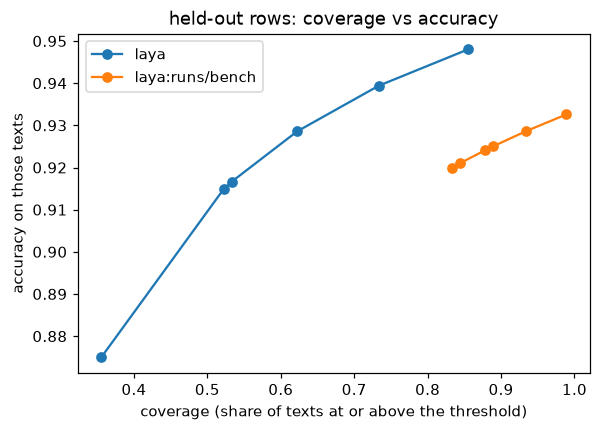

In [5]:
import matplotlib

matplotlib.use("Agg")  # headless: the figure is saved to a file and shown inline, never in a window
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for name, detail in report.details["engines"].items():
    curve = [p for p in detail["label"]["curve"] if p["accuracy"] is not None]
    ax.plot([p["coverage"] for p in curve], [p["accuracy"] for p in curve], marker="o", label=name)
ax.set_xlabel("coverage (share of texts at or above the threshold)")
ax.set_ylabel("accuracy on those texts")
ax.set_title("held-out rows: coverage vs accuracy")
ax.legend()
fig.savefig("coverage_vs_accuracy.png", dpi=110, bbox_inches="tight")
plt.close(fig)
try:
    from IPython.display import Image, display

    display(Image("coverage_vs_accuracy.png"))
except ImportError:
    print("saved coverage_vs_accuracy.png")